<a href="https://colab.research.google.com/github/xujiahengbill-bot/Harris/blob/main/RQ_inventory_simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from __future__ import print_function
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
import random
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def sim(r,q,lt,mean,sigma, days_shown=300):
    np.random.seed(1)   # making sure the random number generator spits out the same sequence every time
    days=3000 # simulate for 1000 days

    demand=np.random.normal(mean,sigma,days).round()   #create our demand

    # Now initialize all the book keeping variables
    sales=np.zeros(days)          # an array where we keep track of sales
    stockouts=np.zeros(days)      # ... stockouts
    incoming=np.zeros(days+lt+1)  # ... inbound inventory
    inv=np.zeros(days+1)          #  ... and inventory itself
    inv_pos=np.zeros(days+lt+1)   # keep track of inventory and 'on_order'
    cycle_count=0                 # to count how many order cyles we had
    perfect_cycle_count=0         # to count how many of them were 'perfect' (no lost sale)
    perfect_cycle=True            # a flag to note when the current cycle fails
    inv[0]=round((r+q/2)/mean)*mean           # a meaningful starting inventory
    inv_pos[0]=inv[0]

    # we are ready and can start the simulation loop
    for d in range(days):   # one for each day

        # if anything is incoming today, add it to inventory
        inv[d]+=incoming[d]

        #count order cycles - if we had an order coming in, we are starting a new one
        if incoming[d]>0:              # we have a new cycle
            cycle_count+=1             # count it
            if perfect_cycle:          # did anything fail in this last cycle?
                perfect_cycle_count+=1 # if not, count it as a perfectcycle
            perfect_cycle=True         # and reset the 'perfect' flag for the next cycle

        # process the sales
        if inv[d]>=demand[d]:          # Do we have more inventory than we need today?
            inv[d+1]=inv[d]-demand[d]    # yes, so just consume the sales
            inv_pos[d+1]=inv_pos[d]-demand[d]
            sales[d]=demand[d]           # log the sales for book keeping
            stockouts[d]=0               # and log that we had no stockouts
        else:
            inv[d+1]=0                   # No, we have a stockout, so our inventory will be fully consumed
            sales[d]=inv[d]              # we will sell only as much as we had
            inv_pos[d+1]=inv_pos[d]-inv[d]
            stockouts[d]=demand[d]-inv[d]# and we need to count the sales we could not fill
            perfect_cycle=False

        # check whether we need to place an order
        if inv[d]+incoming[d+1:d+lt].sum()<=r:
            # yes, we need to place an order
            incoming[d+lt]=q  #place one order of q
            inv_pos[d+1]=inv_pos[d+1]+q



    #and once we are done, let's output a graph of the results
    fig=plt.figure()
    ax0=plt.subplot()  # two plots above each other
    plt.title('R/Q inventory simulation', fontsize=20)
    ax0.plot(inv[0:min(100,days_shown)], label='Inventory')
    ax0.plot(r*np.ones(100), label='R')
    ax0.plot(inv_pos[0:min(100,days_shown)], label='Inventory + on Order', linestyle=':', linewidth=1)
    ax0.legend(loc='best')
    ax0.set_ylim(0,3000)
    ax0.text(10, 2800, f'Fill rate {round(sales.sum()/demand.sum()*100,1)}%', fontsize=15)
    ax0.text(10, 2650, f'Cycle service level {round(perfect_cycle_count/cycle_count*100,1)}%', fontsize=15)
    ax0.text(10, 2500, f'Average inventory {round(inv[50:].mean())} units or {round(inv[50:].mean()/mean,1)} days', fontsize=15)
    ax0.text(10, 2350, f'Demand avg {round(demand.mean())} units', fontsize=15)

    fig.set_size_inches(12,8)
    return



interactive(children=(IntSlider(value=1000, description='r', max=3000, min=100), IntSlider(value=1000, descrip…

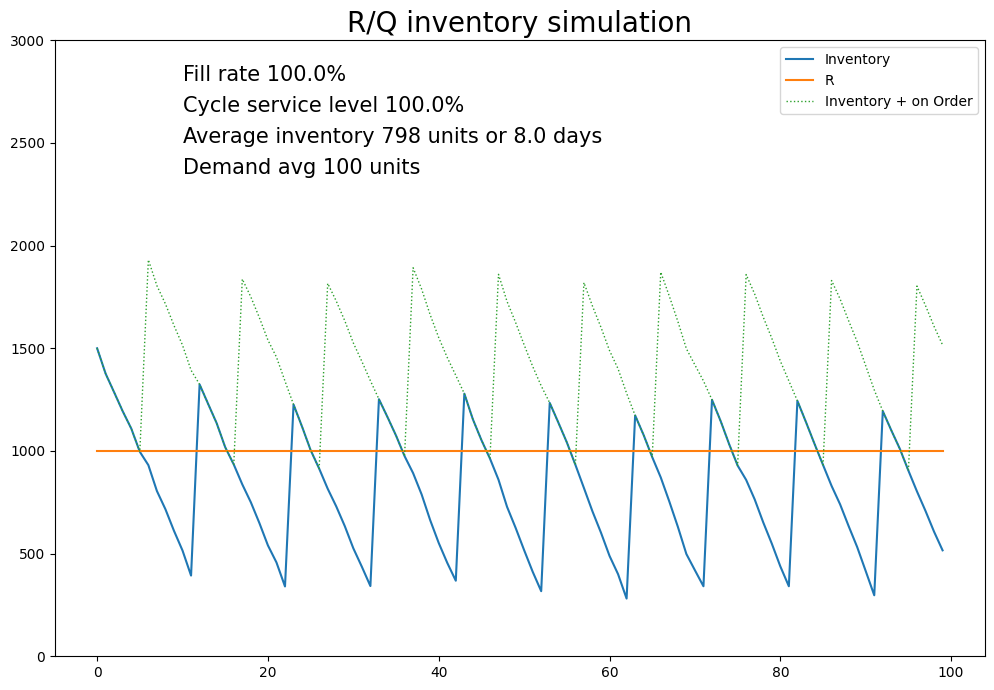

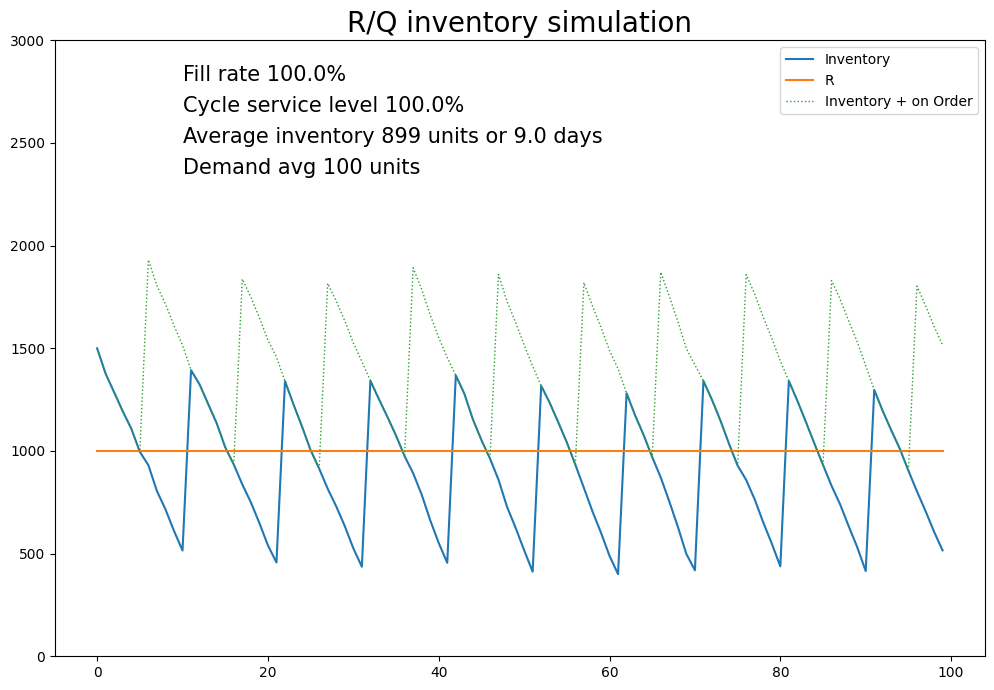

In [ ]:
interact(sim, r=widgets.IntSlider(min=100, max=3000, step=1, value=1000),
        q=widgets.IntSlider(min=200, max=3000, step=50, value=1000),
        lt=widgets.IntSlider(min=1, max=50, step=1, value=7),
        mean=widgets.IntSlider(min=50, max=150, step=1, value=100),
        sigma=widgets.IntSlider(min=0, max=50, step=1, value=15),
        days_shown=widgets.IntSlider(min=0, max=100, step=1, value=100),
        );